<a href="https://colab.research.google.com/github/Tamaki-Baba/data-Econometrics/blob/main/%E3%83%86%E3%82%99%E3%83%BC%E3%82%BF%E3%81%A8%E8%A8%88%E9%87%8F%E7%B5%8C%E6%B8%88%E5%AD%A6_1127.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### ワクチン接種歴がある患者がインフルエンザにかかっている確率(適合率)がどのように変化するかプログラムすることにより数値を導出する

In [ ]:
!pip install japanize_matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 39.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize_matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=55d7b1f5a920640dbc212339d1ccff695753639f6cde990443dfb7e0948736f9
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize_matplotlib


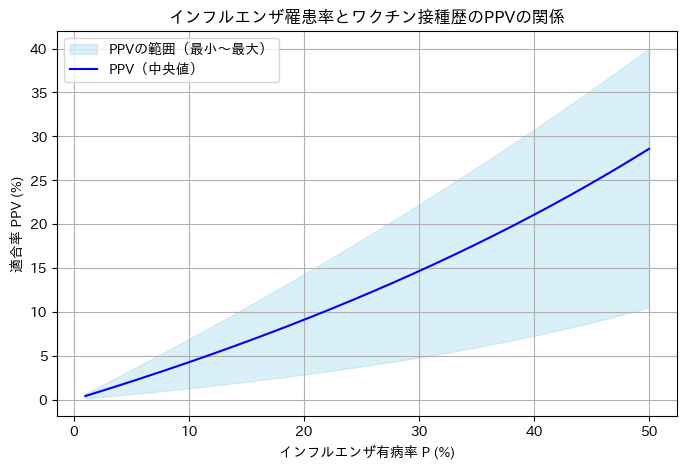

     有病率(%)  PPV_min(%)  PPV_mid(%)  PPV_max(%)
0  1.000000    0.118694    0.402414    0.668896
1  1.246231    0.148246    0.502248    0.834286
2  1.492462    0.177927    0.602379    0.999949
3  1.738693    0.207739    0.702809    1.165886
4  1.984925    0.237683    0.803540    1.332097

--- LR+（陽性尤度比） が高い症状順（診断の役に立つ順）---
            症状       LR+
10  急性発症の発熱と咳嗽  1.968750
9        発熱と咳嗽  1.939394
0           発熱  1.509804
6         くしゃみ  1.152778
7           鼻閉  1.135714
8           悪寒  1.106667
4           頭痛  1.102740
1           咳嗽  1.097561
5          咽頭痛  1.052980
2          筋肉痛  0.987179
3          倦怠感  0.986486
11     ワクチン接種歴  0.400000

--- LR-（陰性尤度比） が低い症状順（除外に役立つ順）---
            症状       LR-
0           発熱  0.469388
9        発熱と咳嗽  0.537313
10  急性発症の発熱と咳嗽  0.544118
1           咳嗽  0.555556
8           悪寒  0.680000
7           鼻閉  0.683333
4           頭痛  0.722222
5          咽頭痛  0.836735
6         くしゃみ  0.914063
3          倦怠感  1.038462
2          筋肉痛  1.045455
11     ワクチン接種歴  

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import japanize_matplotlib

# 1. ワクチン接種歴のPPV計算（中央値＋範囲）

# 感度(Se)・特異度(Sp)の範囲
Se_min, Se_max = 0.02, 0.12
Sp_min, Sp_max = 0.82, 0.83

# 中央値
Se_mid = (Se_min + Se_max) / 2
Sp_mid = (Sp_min + Sp_max) / 2

# 有病率（0.01〜0.50）
P_range = np.linspace(0.01, 0.50, 200)

# PPV計算式
def calculate_ppv(P, Se, Sp):
    return (P * Se) / (P * Se + (1 - P) * (1 - Sp))

# 中央値PPV
PPV_mid = calculate_ppv(P_range, Se_mid, Sp_mid)

# 最小ケース（最低感度 × 最高特異度）
PPV_min = calculate_ppv(P_range, Se_min, Sp_max)

# 最大ケース（最高感度 × 最低特異度）
PPV_max = calculate_ppv(P_range, Se_max, Sp_min)

plt.figure(figsize=(8, 5))

# PPVの帯域（最小～最大）
plt.fill_between(P_range * 100, PPV_min * 100, PPV_max * 100,
                 color='skyblue', alpha=0.3, label='PPVの範囲（最小〜最大）')

# 中央値ライン
plt.plot(P_range * 100, PPV_mid * 100, color='blue', label='PPV（中央値）')

plt.title('インフルエンザ罹患率とワクチン接種歴のPPVの関係')
plt.xlabel('インフルエンザ有病率 P (%)')
plt.ylabel('適合率 PPV (%)')
plt.grid(True)
plt.legend()
plt.show()

df_ppv = pd.DataFrame({
    '有病率(%)': P_range * 100,
    'PPV_min(%)': PPV_min * 100,
    'PPV_mid(%)': PPV_mid * 100,
    'PPV_max(%)': PPV_max * 100
})
print(df_ppv.head())


# 2.その他症状のLR+ / LR-

data = {
    '症状': ['発熱', '咳嗽', '筋肉痛', '倦怠感', '頭痛', '咽頭痛', 'くしゃみ', '鼻閉', '悪寒',
           '発熱と咳嗽', '急性発症の発熱と咳嗽', 'ワクチン接種歴'],
    '感度_min': [0.68, 0.84, 0.60, 0.73, 0.70, 0.75, 0.33, 0.68, 0.83, 0.64, 0.63, 0.02],
    '感度_max': [0.86, 0.96, 0.94, 0.73, 0.91, 0.84, 0.50, 0.91, 0.83, 0.64, 0.63, 0.12],
    '特異度_min': [0.25, 0.07, 0.06, 0.26, 0.11, 0.16, 0.59, 0.19, 0.25, 0.67, 0.68, 0.82],
    '特異度_max': [0.73, 0.29, 0.38, 0.26, 0.43, 0.33, 0.69, 0.41, 0.25, 0.67, 0.68, 0.83]
}

df = pd.DataFrame(data)

# 中央値を使用
df['Se_mid'] = (df['感度_min'] + df['感度_max']) / 2
df['Sp_mid'] = (df['特異度_min'] + df['特異度_max']) / 2

# 尤度比
df['LR+'] = df['Se_mid'] / (1 - df['Sp_mid'])
df['LR-'] = (1 - df['Se_mid']) / df['Sp_mid']

print("\n--- LR+（陽性尤度比） が高い症状順（診断の役に立つ順）---")
print(df[['症状', 'LR+']].sort_values(by='LR+', ascending=False))

print("\n--- LR-（陰性尤度比） が低い症状順（除外に役立つ順）---")
print(df[['症状', 'LR-']].sort_values(by='LR-', ascending=True))
